In [28]:
%pip install azure-ai-vision-face


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /anaconda/envs/azureml_py310_sdkv2/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
from azure.ai.vision.face import FaceClient
from azure.ai.vision.face.models import FaceAttributeType, FaceDetectionModel, FaceRecognitionModel
from azure.core.credentials import AzureKeyCredential
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# Replace with your actual values
KEY = "************"
ENDPOINT = "https://rush-face-api.cognitiveservices.azure.com/"

In [30]:
# Initialize the client
face_client = FaceClient(endpoint=ENDPOINT, credential=AzureKeyCredential(KEY))

In [31]:
# Image containing faces (e.g., Rush band members)
image_url = "RushBandFaces.png"

In [32]:
# Specify attributes to detect
attributes = [
    FaceAttributeType.HEAD_POSE,
    FaceAttributeType.GLASSES,
    FaceAttributeType.BLUR,
    FaceAttributeType.EXPOSURE,
    FaceAttributeType.OCCLUSION
]

In [33]:
print("Detecting faces...")
# Detect faces from the local file
with open(image_url, "rb") as image_stream:
    detected_faces = face_client.detect(
        image_stream.read(),
        return_face_id=False, # Set to False for GA (Generally Available) access
        return_face_landmarks=True,
        return_face_attributes=attributes,
        detection_model=FaceDetectionModel.Detection03,
        recognition_model=FaceRecognitionModel.Recognition04
    )
    
if not detected_faces:
    print("No faces detected.")
else:
    for face in detected_faces:
        # Note: Face ID is restricted and requires approval. 
        # We set return_face_id=False above, so we don't print it here.
        # print(f"Face ID: {face.face_id}") 
        print(f"  Rectangle: {face.face_rectangle}")
        print(f"  Glasses: {face.face_attributes.glasses}")
        print(f"  Head Pose: {face.face_attributes.head_pose}")
        print("-" * 20)

Detecting faces...
  Rectangle: {'top': 126, 'left': 117, 'width': 249, 'height': 360}
  Glasses: NoGlasses
  Head Pose: {'pitch': -16.1, 'roll': 0.3, 'yaw': -4.4}
--------------------
  Rectangle: {'top': 143, 'left': 889, 'width': 248, 'height': 359}
  Glasses: NoGlasses
  Head Pose: {'pitch': -7.0, 'roll': -2.0, 'yaw': 3.1}
--------------------
  Rectangle: {'top': 139, 'left': 491, 'width': 248, 'height': 343}
  Glasses: Sunglasses
  Head Pose: {'pitch': -21.9, 'roll': 1.9, 'yaw': -14.1}
--------------------


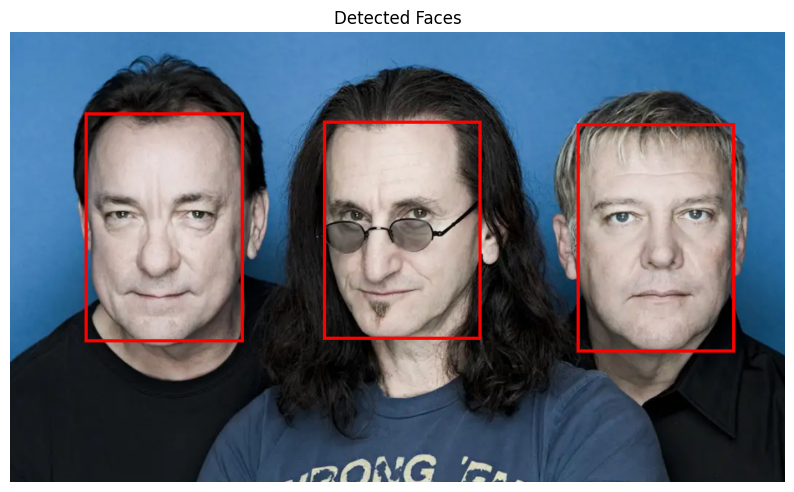

In [34]:
# Visualize the results
img = Image.open("RushBandFaces.png")
draw = ImageDraw.Draw(img)

for face in detected_faces:
    rect = face.face_rectangle
    # Draw the bounding box
    left = rect.left
    top = rect.top
    right = left + rect.width
    bottom = top + rect.height
    draw.rectangle([left, top, right, bottom], outline="red", width=5)

# Show the image
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Detected Faces")
plt.show()